## Basics

In [1]:
#import relevant libraries
import os
from scipy import stats
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime


date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap
import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import osar 

#NOTE: SUPPRESSES WARNINGS!

import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

print(osar.__version__)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 22.24it/s]


Numba compilation complete!
0.23.9


In [2]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp
filedate = "20251023"

filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\2025collection\\"
filedirectory_Falling = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\Compilation with delta\\2025deltagcollection\\"
filesavedir = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Totalosarfalling\\images\\"

In [3]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

## Function

In [4]:
def find_number(df, lookup_value, genre):
    lobe_values = []
    for _, row in df.iterrows():
        # Splitting the 'MBON' values and removing any potential whitespace
        mbon_values = [x.strip() for x in row['MBON names'].split(',')]
        if lookup_value in mbon_values:
            lobe_values.append(row[genre])
            
    lobelobe = list(set(lobe_values))
    return ', '.join(lobelobe)

def MBONnamefile(MBONList, pathfile):
    #reading mbonlist file

    #MBONFILEDIRECTORY: specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\"
    directorynew = os.path.dirname(os.path.dirname(pathfile)) #goes up one directory
    fileinnewdirc = os.listdir(directorynew)

    for file_no2 in fileinnewdirc:
        if ".csv" in file_no2:
            ff = os.path.join(directorynew, file_no2)
            csvfile = pd.read_csv(ff)

    csvfile = csvfile.astype('string')

    for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
        csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

    lobelocation = pd.DataFrame()

    for m in MBONList:
        lobeloc = pd.DataFrame()
        lobeloc['MBON'] = [m]
        loclst = find_number(csvfile, m, "Lobe")
        mbonlst = find_number(csvfile, m, "MBON number").strip()
        ntlst = find_number(csvfile, m, "Neurotransmitter")
        lobeloc['Lobe_location'] = [loclst]
        lobeloc['MBON number'] = [mbonlst]
        lobeloc['Neurotransmitter'] = [ntlst]
        
        lobelocation = pd.concat([lobelocation, lobeloc])

    lobelocation = lobelocation.reset_index(drop=True)
    return lobelocation

def matchingdfs (df, matchingset):
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = df[(df['MBON'] == n)]
        newdf_a = pd.concat([newdf_a, df_a]).reset_index(drop=True)
    return newdf_a

import textwrap

def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)
    
def matchinglobesets(dfreg_a, lobelocation):
    lobelocation_a = lobelocation.sort_values(by=['MBON']).reset_index(drop=True)
    dfreg_a_withloc = dfreg_a.sort_values(by=['MBON']).reset_index(drop=True)
    matchinglobereg = list(set(lobelocation_a['MBON']) & set(dfreg_a_withloc['MBON']))

    dflobe_reg = matchingdfs(lobelocation_a, matchinglobereg).sort_values(by=['MBON']).reset_index(drop=True)

    dfreg_a_withloc['Lobe_location'] = dflobe_reg['Lobe_location']
    dfreg_a_withloc['MBON number'] = dflobe_reg['MBON number']
    dfreg_a_withloc['Neurotransmitter'] = dflobe_reg['Neurotransmitter']

    return dfreg_a_withloc


def matchingcomp(dfreg_Cr2, osar_multiplot_cr2):
    matchingset = list(set(dfreg_Cr2['MBON']) & set(osar_multiplot_cr2['MBON']))
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = dfreg_Cr2[(dfreg_Cr2['MBON'] == n)]
        df_b = pd.merge(df_a, osar_multiplot_cr2, on = "MBON" )
        newdf_a = pd.concat([newdf_a, df_b]).reset_index(drop=True)
    return newdf_a
        
def omission(df):
    tempdff = df[df['MBON'] != 'VT999036'].reset_index(drop=True) #removing outlier
    #dfomitted = tempdff[~((tempdff['PI_Δg_OSAR'].abs() < 0.2) & (tempdff['Log2 Bout Speed ratio_Δg_OSAR'].abs() < 0.2))]
    dfomitted = tempdff[~((tempdff['PI_Δg_OSAR'].abs() < 0.2) )]
   
    return dfomitted.reset_index(drop=True)

## Formulas to run


In [5]:
fallingexcel = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Falling.xlsx")
MBONList = list(fallingexcel['MBON'].unique())

lobelocation = MBONnamefile(MBONList, specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\")

## Code

## reg plots

In [7]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "Chrimson2"

# Define the three condition files
conditions = ['Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + condition + ".xlsx")
    
    df_nt2 = totalmetriccomparison.drop(columns=['genotypeandresponder'])
    df_nt2 = df_nt2[~df_nt2['MBON'].isin(['VT999036'])]
    
    ntloblist = []
    mbonloclst = []
    df_nttotal = df_nt2.copy()
    for n in df_nt2['MBON']:    
        ntloblist.append(lobelocation[lobelocation['MBON'] == n]['Neurotransmitter'].values[0])
        mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
    df_nttotal['NT'] = ntloblist
    df_nttotal['Name'] = mbonloclst
    
    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_neurotrans = df_nttotal[df_nttotal['responder']=="Chrimson2"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colorline = 'red'
        nttypes_color = ['mediumorchid', "darkorange", "slategrey"]
    
    if responder == 'ACR':
        responderrename = "GtACR1"
        df_neurotrans = df_nttotal[df_nttotal['responder']=="ACR"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colorline = 'green'
        nttypes_color = ['blue', "darkturquoise", "indigo"]
    
    
    figntplot, axes = plt.subplots(3,4, figsize=(20,15))
    axscatter_nt = axes.flatten()
    nttypes = ['Glutamate', "Acetylcholine", "GABA"]
    
    metrictype = ['Log2 Speed ratio_Δg_Falling', 'Log2 Bout Speed ratio_Δg_Falling', 'Log2 Speed ratio_Δg_OSAR', 'Log2 Bout Speed ratio_Δg_OSAR']
    plotcounter = 0
    
    for n,j in zip(nttypes, nttypes_color):
        unfiltered_dfnt = df_neurotrans[df_neurotrans['NT'] == n].reset_index(drop=True)
        
        for k in metrictype:
            x_label_1 = k
            y_label_1 = 'PI_Δg_OSAR'      

            data_nt = unfiltered_dfnt[~((unfiltered_dfnt[x_label_1].abs() < 0.2) & (unfiltered_dfnt[y_label_1].abs() < 0.2))].reset_index(drop=True)
            #data_nt = unfiltered_dfnt.copy()
          
            sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=95, scatter=False, line_kws={"color": "black"}, ax=axscatter_nt[plotcounter])
            sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=0, scatter=False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_nt[plotcounter])
            sns.scatterplot(x=x_label_1, y=y_label_1, data=data_nt, s=40, color=j, edgecolors="face", ax=axscatter_nt[plotcounter])
    
            axscatter_nt[plotcounter].grid(False)
            axscatter_nt[plotcounter].set_ylim([-1.5, 1.5])
            axscatter_nt[plotcounter].set_xlim([-1.5, 1.5])
            axscatter_nt[plotcounter].axvline(0, c=(.5, .5, .5), ls='--')
            axscatter_nt[plotcounter].axhline(0, c=(.5, .5, .5), ls='--')
           
            axscatter_nt[plotcounter].yaxis.set_tick_params(labelbottom=True)
    
            for m, p in enumerate(data_nt['MBON']):
                axscatter_nt[plotcounter].annotate(p, (data_nt.loc[m,x_label_1], data_nt.loc[m,y_label_1]+0.01), fontsize=10)
    
            # Correlation for subplot
            pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(data_nt[x_label_1], data_nt[y_label_1])
            civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
            civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
            axscatter_nt[plotcounter].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), 
                                    (0.02, 0.05), ha="left", xycoords='axes fraction', weight="bold", fontsize=8)
            
            # Naming of nt type
            axscatter_nt[plotcounter].annotate(n, (0.02, 0.12), ha="left", xycoords='axes fraction', color=j, weight="bold", fontsize=8)
            plotcounter += 1
            
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, wspace=0.2, hspace=0.3)
    
    figntplot.suptitle(f"MBONs > {responderrename}_Linear regressions across NT types ({condition})", weight="bold", fontfamily="Inter", fontsize=16)
    
    # plt.savefig(filesavedir + date + "_" + responder + "_linreg_nttypes_" + condition + ".png", dpi=1200, bbox_inches='tight')
    # plt.savefig(filesavedir + date + "_" + responder + "_linreg_nttypes_" + condition + ".svg")
    
    plt.show()
    
    print(f"Generated plot for {condition} condition")

KeyError: 'PI_Δg_OSAR'

## clustering code

In [9]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "Chrimson2"

totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-Full.xlsx")

df_nt2 = totalmetriccomparison.drop(columns=['genotypeandresponder', 'Speed ratio_Hg_OSAR',
       'Bout Speed ratio_Hg_OSAR'])
df_nt2 = df_nt2[~df_nt2['MBON'].isin(['VT999036'])]

ntloblist = []
mbonloclst = []
df_nttotal = df_nt2.copy()
for n in df_nt2['MBON']:    
    ntloblist.append(lobelocation[lobelocation['MBON'] == n]['Neurotransmitter'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df_nttotal['NT'] = ntloblist
df_nttotal['Name'] = mbonloclst

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_neurotrans = df_nttotal[df_nttotal['responder']=="Chrimson2"]
    colorline = 'red'
    nttypes_color = ['mediumorchid', "darkorange", "slategrey"]

if responder == 'ACR':
    responderrename = "GtACR1"
    df_neurotrans = df_nttotal[df_nttotal['responder']=="ACR"]
    colorline = 'green'
    nttypes_color = ['blue', "darkturquoise", "indigo"]
    
#g = sns.PairGrid(plot_data, vars=key_metrics, hue = 'NT')

In [10]:
singlecellmbon = ['MB018B',
'MB080C',
'MB085C',
'MB091C',
'MB112C',
'MB242A',
'MB262B',
'MB298B',
'MB399B',
'MB622B',
'SS01127',
'SS01143',
'SS01188',
'SS01194',
'SS01308',
'SS01337',
'SS01388',
'SS46348',
'SS67662',
'SS67727',
'SS67728',
'SS67741',
'SS67755',
'SS75199',
'SS75200',
'SS76094',
'SS77383',
'SS77424',
'SS77450',
'SS80974',
'SS81353',
'SS81521',
'SS95118',
'SS97567']


In [17]:
mode = "single"

df_nta = df_neurotrans.drop(columns = ['responder', 'Name'])

metricsidontwant = [ 'Pause position_Δg_Falling',  'Duration of bouts_Δg_Falling','Number of Bouts_Δg_Falling',   
                    'Max velocity_Δg_Falling', 'Bout speed_Δg_Falling',  'Speed_Δg_Falling', 'Speed ratio_Hg_OSAR',
                    'Bout Speed ratio_Hg_OSAR', 'genotypeandresponder']

specificmetricdf = df_nta[[col for col in df_nta.columns if col not in metricsidontwant]]

df_allmbons = specificmetricdf.set_index('MBON')
df_nt_singlecell = specificmetricdf[specificmetricdf['MBON'].isin(singlecellmbon)].set_index('MBON')
df_nt_multicell = specificmetricdf[~specificmetricdf['MBON'].isin(singlecellmbon)].set_index('MBON')

if mode == "single":
    datasettouse = df_nt_singlecell
    modename = "Single celled"
elif mode == "multi":
    datasettouse = df_nt_multicell
    modename = "Multi celled"
elif mode == "all":
    datasettouse = df_allmbons
    modename = "Single and Multi-celled"

## Pairplot

In [67]:
df_nt_singlecell.columns

Index(['Fall number_ΔΔ_Falling', 'Speed_Δg_Falling',
       'Max height climbed_Δg_Falling', 'Bout speed_Δg_Falling',
       'Pause position_Δg_Falling', 'Max velocity_Δg_Falling',
       'Straightness Index_Δg_Falling', 'Duration of bouts_Δg_Falling',
       'Number of Bouts_Δg_Falling', 'Log2 Bout Speed ratio_Hg_Falling',
       'Log2 Speed ratio_Hg_Falling', 'Bout number index_Hg_Falling',
       'Bout duration ratio_Hg_Falling', 'Max velocity_Hg_Falling',
       'PI_Hg_OSAR', 'Log2 Speed ratio_Hg_OSAR',
       'Log2 Bout Speed ratio_Hg_OSAR', 'Light Attraction Index_Hg_OSAR',
       'Bout Number Index_Hg_OSAR', 'Bout Duration ratio_Hg_OSAR',
       'Max Velocity ratio_Hg_OSAR', 'NT'],
      dtype='object')

In [72]:
metriccolumns = ['Fall number_ΔΔ_Falling', 'Speed_Δg_Falling',
       'Max height climbed_Δg_Falling', 'Bout speed_Δg_Falling', 'Pause position_Δg_Falling',
       'Max velocity_Δg_Falling',
       'Straightness Index_Δg_Falling', 'Duration of bouts_Δg_Falling',
       'Number of Bouts_Δg_Falling', 
       
       'PI_Hg_OSAR', 'Log2 Speed ratio_Hg_OSAR',
       'Log2 Bout Speed ratio_Hg_OSAR', 'Light Attraction Index_Hg_OSAR',
       'Bout Number Index_Hg_OSAR', 'Bout Duration ratio_Hg_OSAR',
       'Max Velocity ratio_Hg_OSAR', 'NT']

df_nt_metricreduce = datasettouse[metriccolumns]

In [73]:
import pandas as pd
from scipy.stats import pearsonr
import itertools

# Get all pairwise combinations of your 16 variables
variables = df_nt_metricreduce.columns.tolist()[:-1]  # Adjust if you need to exclude some columns

results = []

# Calculate Pearson correlation for each pair
for var1, var2 in itertools.combinations(variables, 2):
    # Remove NaN values for each pair
    mask = df_nt_metricreduce[[var1, var2]].notna().all(axis=1)
    x = df_nt_metricreduce.loc[mask, var1]
    y = df_nt_metricreduce.loc[mask, var2]
    
    if len(x) > 0:  # Make sure we have data
        r, _ = pearsonr(x, y)
        r_squared = r ** 2
        results.append({
            'Metric 1': var1,
            'Metric 2': var2,
            'Pearson Coefficient': r,
            'R2': r_squared
        })


correlation_table = pd.DataFrame(results)
correlation_table = correlation_table.sort_values('R2', ascending=False).reset_index(drop=True)

#correlation_table.to_csv('pearson_correlations.csv', index=False)


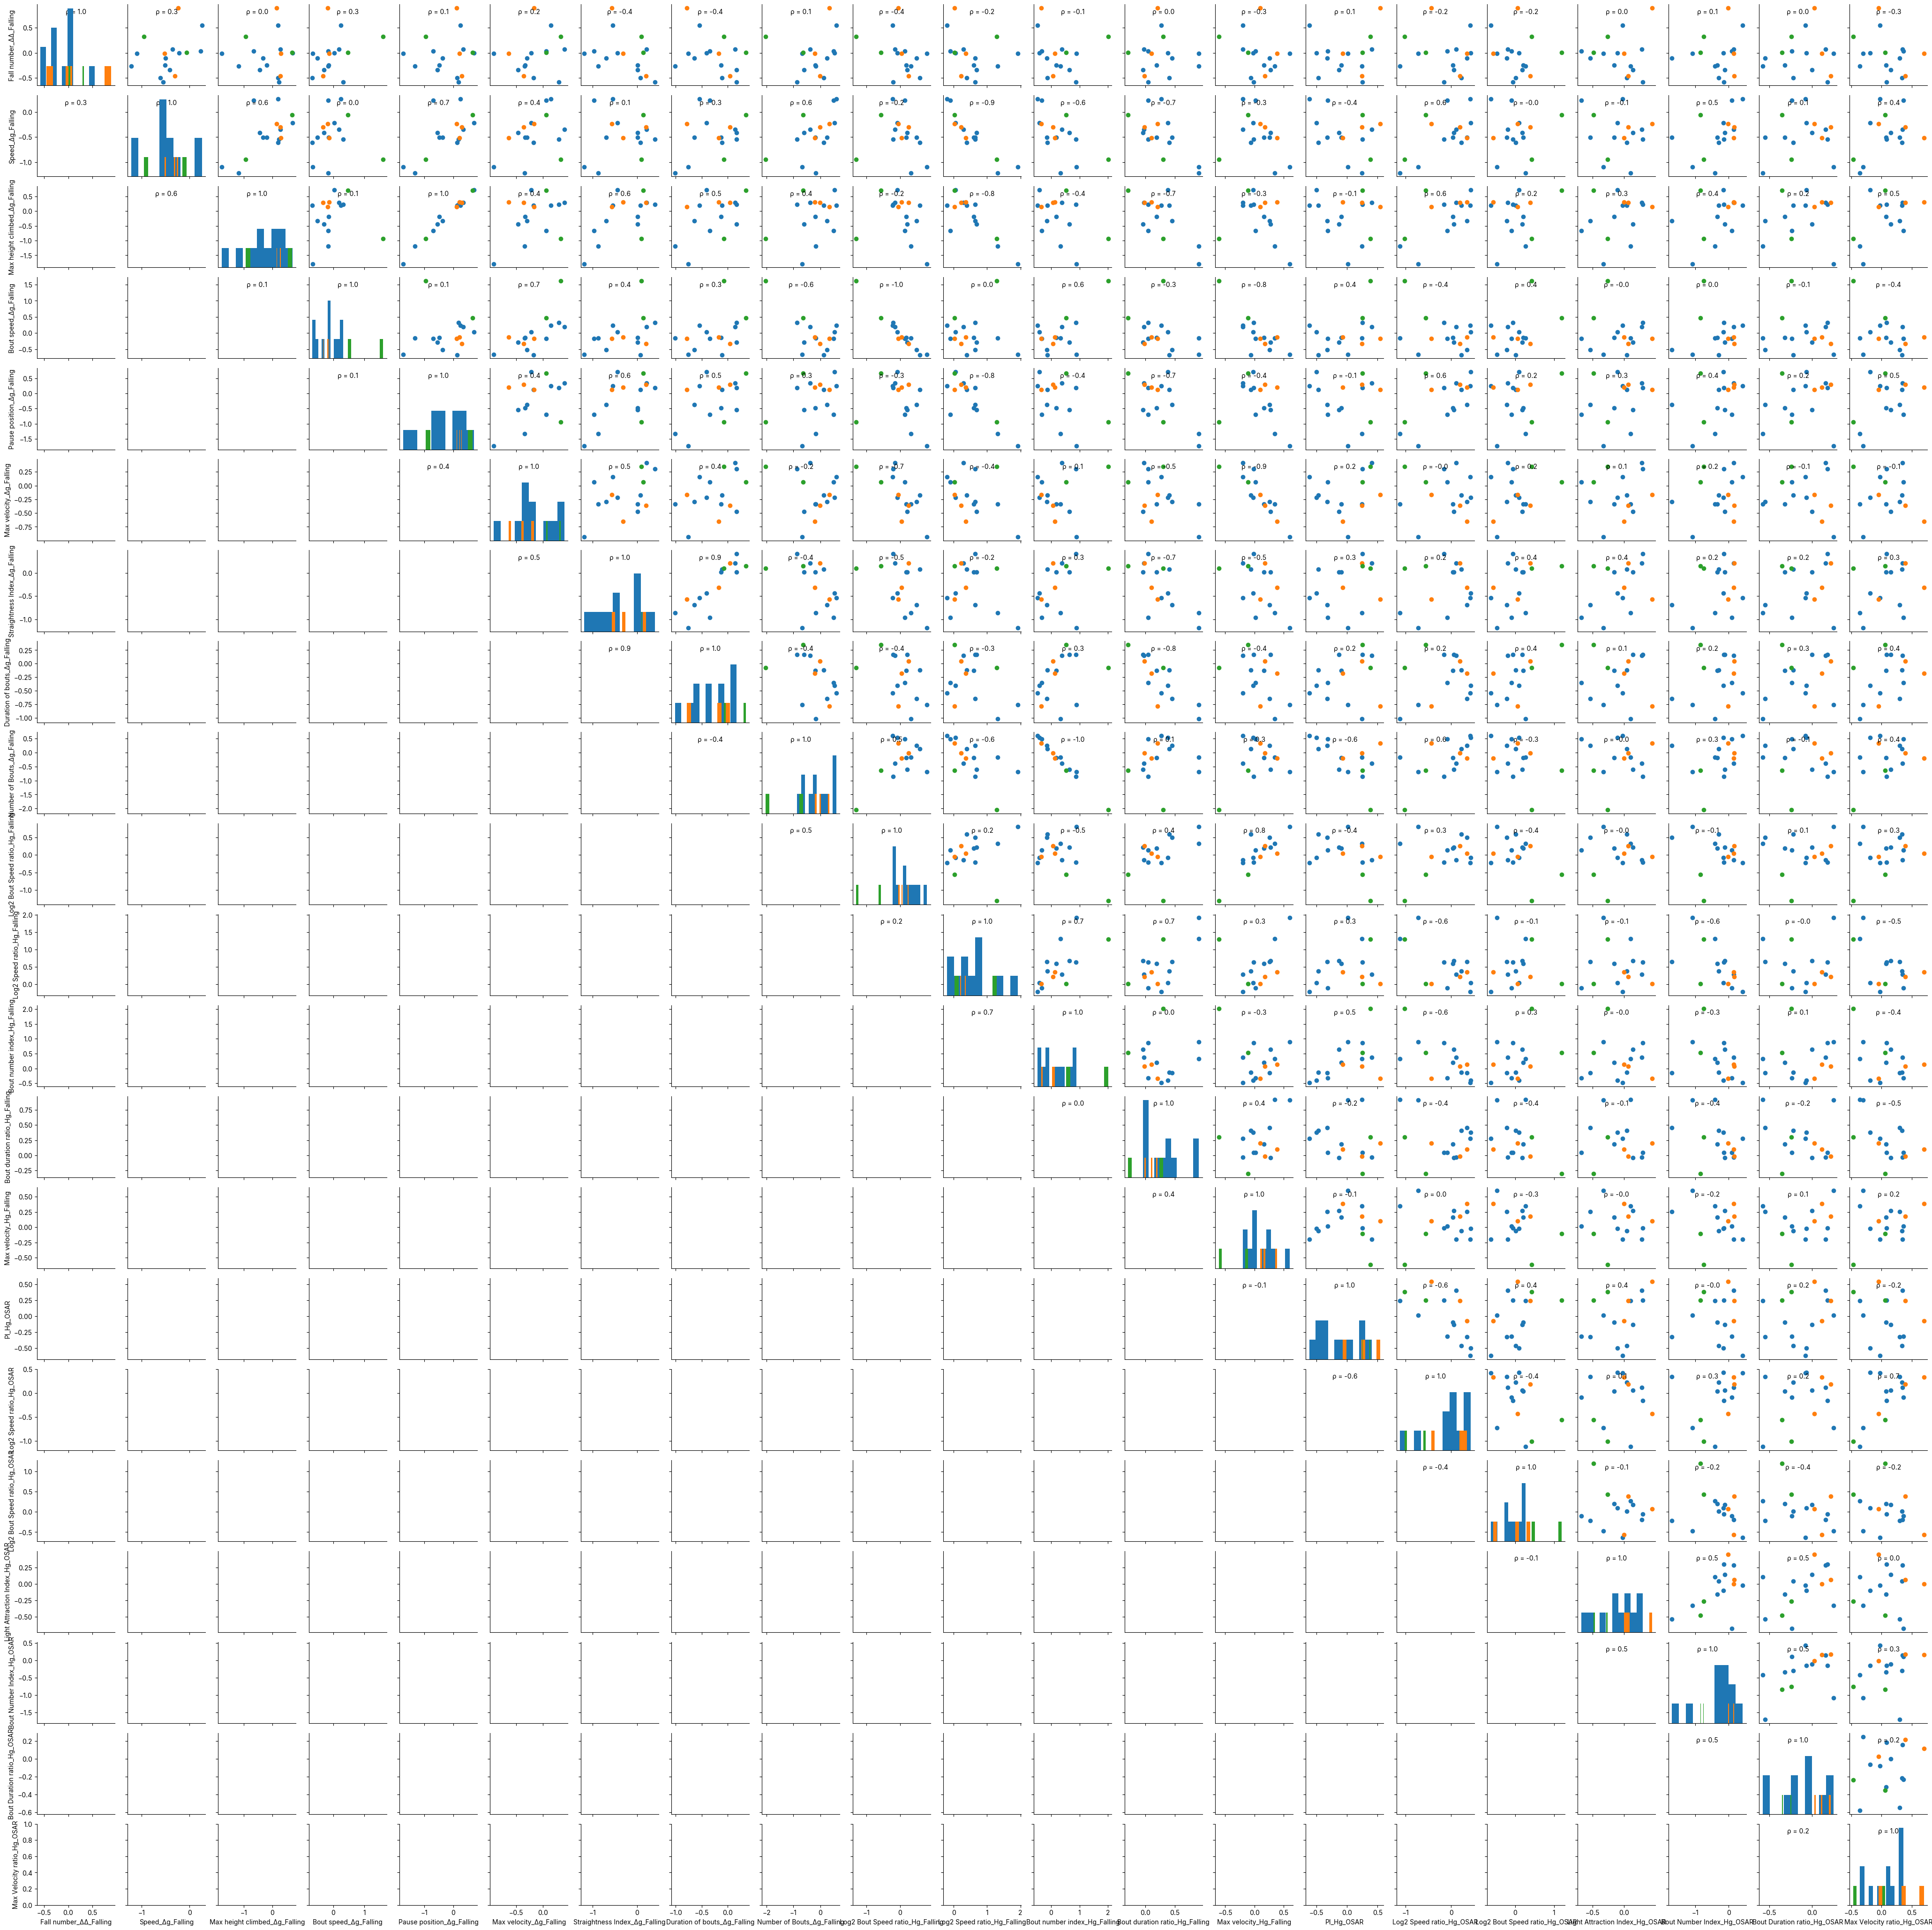

In [34]:
g = sns.PairGrid(df_nt_singlecell, hue = 'NT',height = 2.0)
g.map_diag(plt.hist)
g.map_upper(plt.scatter)
# g.map_lower(corrfunc)

for i, j in zip(*np.triu_indices_from(g.axes, k=-1)):
    corrfunc(df_nt_singlecell.iloc[:, j], 
             df_nt_singlecell.iloc[:, i], 
             ax=g.axes[i, j])

In [ ]:
fig, axes = plt.subplots(figsize=(16,4))
## code taken from another msvcode
df89 = pd.melt(df50, id_vars = ['Neurotransmitter'], var_name = 'Metrics', value_name = "Δg")
g1 = sns.swarmplot(data=df89, x= 'Metrics', y = 'Δg', hue='Neurotransmitter',dodge = True)
sns.move_legend(g1, "upper left", bbox_to_anchor=(1, 1))
sns.set_style("darkgrid")
wrap_labels(axes, 10)

## NT code

In [19]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

# Prepare data for clustering
df_clustermbons = datasettouse.copy()
df_cluster = df_clustermbons.drop(columns=['NT']).fillna(0)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_cluster)

# Apply 4 clustering methods
n_clusters = 3

# K-means
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(data_scaled)

# Hierarchical
hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
hierarchical_labels = hierarchical.fit_predict(data_scaled)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=2)
dbscan_labels = dbscan.fit_predict(data_scaled)

# Gaussian Mixture
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm_labels = gmm.fit_predict(data_scaled)

# Calculate silhouette scores
sil_kmeans = silhouette_score(data_scaled, kmeans_labels)
sil_hierarchical = silhouette_score(data_scaled, hierarchical_labels)
sil_dbscan = silhouette_score(data_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1
sil_gmm = silhouette_score(data_scaled, gmm_labels)

# Create results dataframe
results = pd.DataFrame({
    'Method': ['K-means', 'Hierarchical', 'DBSCAN', 'GMM'],
    'Silhouette Score': [sil_kmeans, sil_hierarchical, sil_dbscan, sil_gmm],
    'N Clusters': [len(set(kmeans_labels)), len(set(hierarchical_labels)), 
                   len(set(dbscan_labels)), len(set(gmm_labels))]
})

print("Clustering Comparison Results:")
print(results.sort_values('Silhouette Score', ascending=False))

best_method = results.loc[results['Silhouette Score'].idxmax(), 'Method']
print(f"\nBest method: {best_method}")

# Add cluster labels to dataframe
df_clustermbons_clustered = df_clustermbons.copy()
df_clustermbons_clustered['KMeans'] = kmeans_labels
df_clustermbons_clustered['Hierarchical'] = hierarchical_labels
df_clustermbons_clustered['DBSCAN'] = dbscan_labels
df_clustermbons_clustered['GMM'] = gmm_labels

# Compare with neurotransmitter types
print("\nClustering vs Neurotransmitter Alignment:")
for method, labels in [('KMeans', kmeans_labels), ('Hierarchical', hierarchical_labels), 
                       ('DBSCAN', dbscan_labels), ('GMM', gmm_labels)]:
    ari = adjusted_rand_score(df_clustermbons['NT'].factorize()[0], labels)
    print(f"{method}: ARI = {ari:.3f}")

# PCA for visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)
df_clustermbons_clustered['PCA1'] = pca_data[:, 0]
df_clustermbons_clustered['PCA2'] = pca_data[:, 1]

Clustering Comparison Results:
         Method  Silhouette Score  N Clusters
1  Hierarchical          0.293330           3
0       K-means          0.264257           3
3           GMM          0.264257           3
2        DBSCAN         -1.000000           1

Best method: Hierarchical

Clustering vs Neurotransmitter Alignment:
KMeans: ARI = 0.200
Hierarchical: ARI = 0.252
DBSCAN: ARI = 0.000
GMM: ARI = 0.200


MBONs with at least one |Δg| > 0.2: 16/16
Clustering on 16 MBONs × 15 metrics
k=2: Silhouette Score = 0.293
k=3: Silhouette Score = 0.293
k=4: Silhouette Score = 0.181
k=5: Silhouette Score = 0.170
k=6: Silhouette Score = 0.162
k=7: Silhouette Score = 0.164

Optimal k by Silhouette: 3


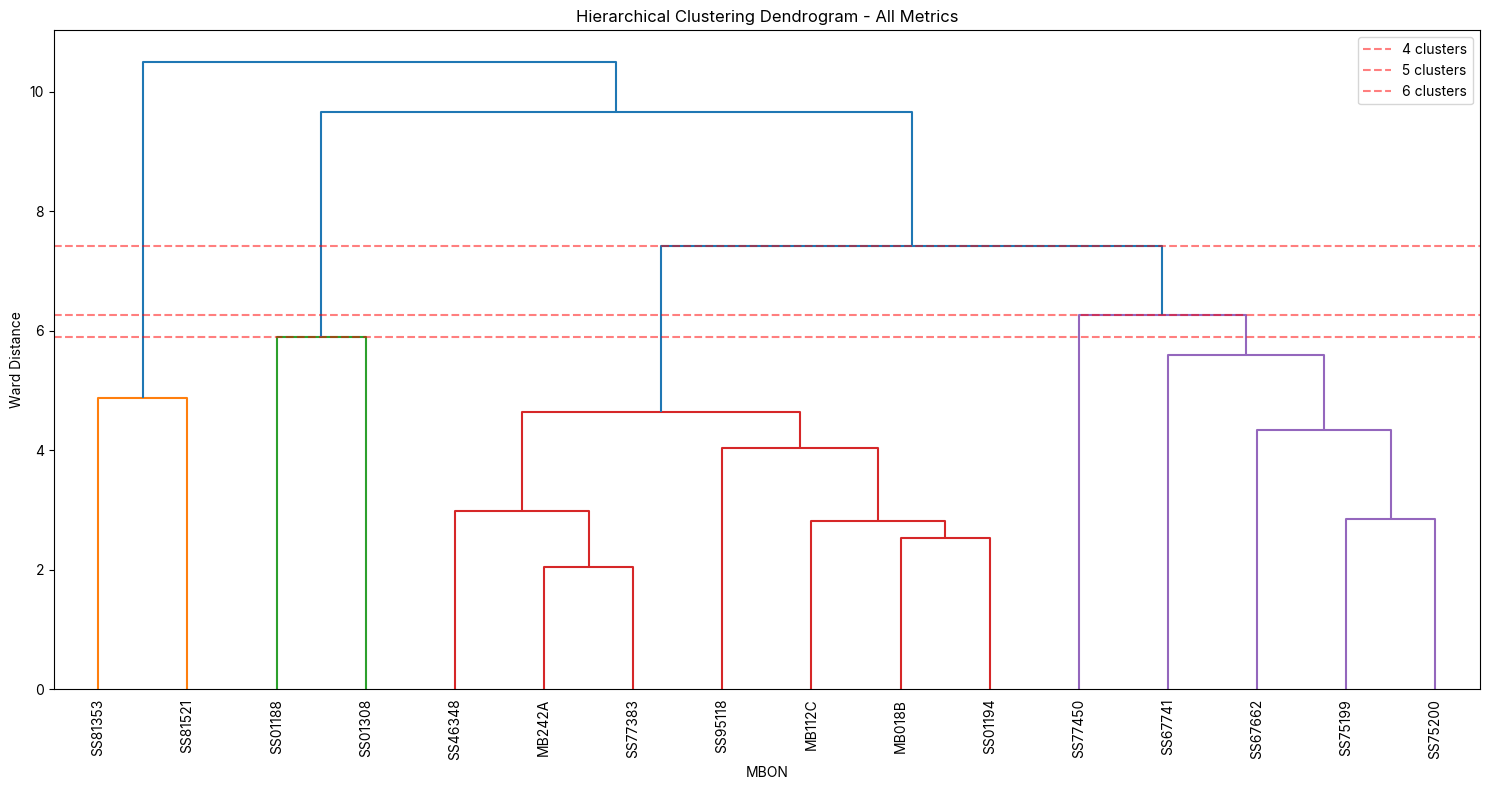

ward: Silhouette = 0.293
average: Silhouette = 0.293
complete: Silhouette = 0.264


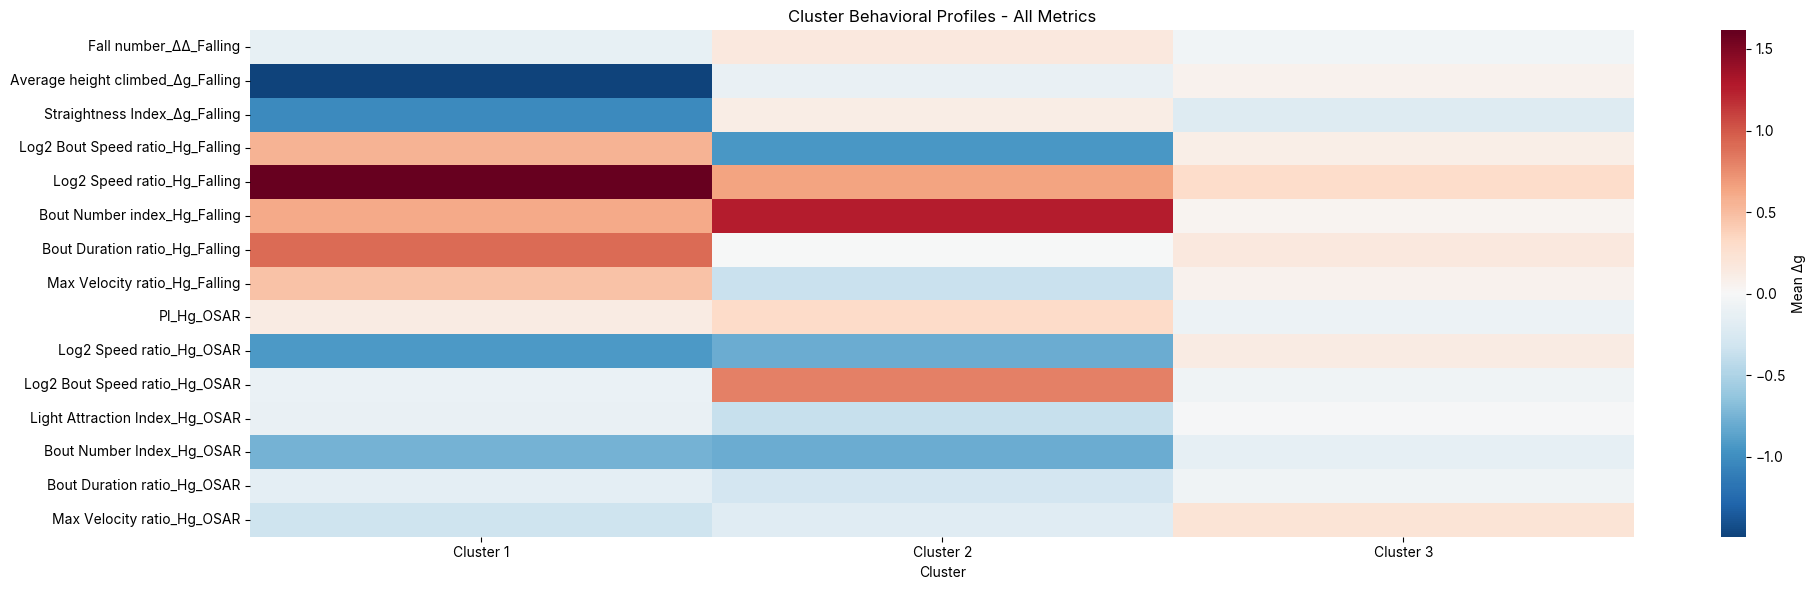


Cluster 1 characteristics:
Strongest positive effects:
  Log2 Speed ratio_Hg_Falling: 1.61
  Bout Duration ratio_Hg_Falling: 0.91
  Bout Number index_Hg_Falling: 0.61
Strongest negative effects:
  Average height climbed_Δg_Falling: -1.49
  Straightness Index_Δg_Falling: -1.02
  Log2 Speed ratio_Hg_OSAR: -0.92
Behavioral category: Multi-context
MBONs in cluster: 2

Cluster 2 characteristics:
Strongest positive effects:
  Bout Number index_Hg_Falling: 1.27
  Log2 Bout Speed ratio_Hg_OSAR: 0.81
  Log2 Speed ratio_Hg_Falling: 0.66
Strongest negative effects:
  Log2 Bout Speed ratio_Hg_Falling: -0.93
  Bout Number Index_Hg_OSAR: -0.80
  Log2 Speed ratio_Hg_OSAR: -0.79
Behavioral category: Multi-context
MBONs in cluster: 2

Cluster 3 characteristics:
Strongest positive effects:
  Log2 Speed ratio_Hg_Falling: 0.30
  Max Velocity ratio_Hg_OSAR: 0.21
Strongest negative effects:
  Straightness Index_Δg_Falling: -0.21
Behavioral category: Weak/Modulatory
MBONs in cluster: 12


In [21]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


df_clustermbons = datasettouse.copy()
df_cluster = df_clustermbons.drop(columns=['NT'])  # Keep ALL behavioral metrics
df_cluster = df_cluster.fillna(0)

# Optional: Apply effect size filter per MBON (not per metric)
# Keep MBONs that have at least ONE meaningful effect
min_effect_threshold = 0.2
mask = (df_cluster.abs() > min_effect_threshold).any(axis=1)
df_filtered = df_cluster[mask]
print(f"MBONs with at least one |Δg| > {min_effect_threshold}: {len(df_filtered)}/{len(df_cluster)}")

# 2. STANDARDIZE ALL METRICS
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_filtered)
print(f"Clustering on {data_scaled.shape[0]} MBONs × {data_scaled.shape[1]} metrics")

# 3. DETERMINE OPTIMAL CLUSTERS
# Method 1: Silhouette analysis
silhouette_scores = []
K_range = range(2, min(10, len(df_filtered)//2))

for k in K_range:
    clusterer = AgglomerativeClustering(n_clusters=k, linkage='ward')
    cluster_labels = clusterer.fit_predict(data_scaled)
    silhouette_avg = silhouette_score(data_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"k={k}: Silhouette Score = {silhouette_avg:.3f}")

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal k by Silhouette: {optimal_k}")

# Method 2: Dendrogram inspection
linkage_matrix = linkage(data_scaled, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, 
           labels=df_filtered.index.tolist(),
           leaf_rotation=90,
           leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram - All Metrics')
plt.xlabel('MBON')
plt.ylabel('Ward Distance')

# Add horizontal lines at different cut heights
for k in [3, 4, 5]:
    threshold = linkage_matrix[-k, 2]
    plt.axhline(y=threshold, c='r', linestyle='--', alpha=0.5, 
                label=f'{k+1} clusters')
plt.legend()
plt.tight_layout()
plt.show()

# 4. ANALYZE CLUSTER STABILITY
# Try different linkage methods to see if clusters are robust
linkage_methods = ['ward', 'average', 'complete']
results_comparison = {}

for method in linkage_methods:
    link_matrix = linkage(data_scaled, method=method)
    clusters = fcluster(link_matrix, optimal_k, criterion='maxclust')
    sil_score = silhouette_score(data_scaled, clusters)
    results_comparison[method] = {
        'clusters': clusters,
        'silhouette': sil_score
    }
    print(f"{method}: Silhouette = {sil_score:.3f}")

# 5. FINAL CLUSTERING WITH BEST METHOD
best_method = max(results_comparison, key=lambda x: results_comparison[x]['silhouette'])
final_clusters = results_comparison[best_method]['clusters']

df_clustered = df_filtered.copy()
df_clustered['Cluster'] = final_clusters

# 6. CHARACTERIZE CLUSTERS
# Look at mean effect sizes per cluster across ALL metrics
cluster_profiles = df_clustered.groupby('Cluster').mean()

# Heatmap of cluster profiles
plt.figure(figsize=(20, 6))
sns.heatmap(cluster_profiles.T, cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Mean Δg'}, 
            xticklabels=[f'Cluster {i}' for i in cluster_profiles.index],
            yticklabels=cluster_profiles.columns)
plt.title('Cluster Behavioral Profiles - All Metrics')
plt.tight_layout()
plt.show()

# 7. IDENTIFY WHAT MAKES EACH CLUSTER UNIQUE
for cluster_id in cluster_profiles.index:
    print(f"\nCluster {cluster_id} characteristics:")
    profile = cluster_profiles.loc[cluster_id]
    
    # Find strongest effects (positive and negative)
    top_positive = profile.nlargest(3)
    top_negative = profile.nsmallest(3)
    
    print("Strongest positive effects:")
    for metric, value in top_positive.items():
        if value > 0.2:
            print(f"  {metric}: {value:.2f}")
    
    print("Strongest negative effects:")
    for metric, value in top_negative.items():
        if value < -0.2:
            print(f"  {metric}: {value:.2f}")
    
    # Classify behaviorally
    osar_effects = profile[[col for col in profile.index if 'OSAR' in col]].abs().mean()
    falling_effects = profile[[col for col in profile.index if 'Falling' in col]].abs().mean()
    
    if osar_effects > 0.3 and falling_effects < 0.2:
        category = "OSAR-dominant"
    elif falling_effects > 0.3 and osar_effects < 0.2:
        category = "Falling-dominant"
    elif osar_effects > 0.2 and falling_effects > 0.2:
        category = "Multi-context"
    else:
        category = "Weak/Modulatory"
    
    print(f"Behavioral category: {category}")
    print(f"MBONs in cluster: {(df_clustered['Cluster'] == cluster_id).sum()}")

In [37]:
# 1. Let the hierarchical clustering define the groups
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
cluster_labels = hierarchical.fit_predict(data_scaled)

# 2. Look at the RAW patterns for each cluster
# Don't average or categorize yet - just observe
for cluster_id in range(3):
    cluster_mbons = df_clustered[df_clustered['Cluster'] == cluster_id]
    
    print(f"\nCluster {cluster_id + 1}:")
    print(f"Number of MBONs: {len(cluster_mbons)}")
    
    # Show the actual mean values for EACH metric separately
    print("\nMean Δg values:")
    for metric in df_clustered.columns:
        if metric != 'Cluster':
            mean_val = cluster_mbons[metric].mean()
            std_val = cluster_mbons[metric].std()
            print(f"  {metric}: {mean_val:.3f} ± {std_val:.3f}")
    
    # Let the pattern speak for itself
    # Don't force categories


Cluster 1:
Number of MBONs: 0

Mean Δg values:
  Fall number_ΔΔ_Falling: nan ± nan
  Average height climbed_Δg_Falling: nan ± nan
  Straightness Index_Δg_Falling: nan ± nan
  Log2 Bout Speed ratio_Hg_Falling: nan ± nan
  Log2 Speed ratio_Hg_Falling: nan ± nan
  Bout Number index_Hg_Falling: nan ± nan
  Bout Duration ratio_Hg_Falling: nan ± nan
  Max Velocity ratio_Hg_Falling: nan ± nan
  PI_Hg_OSAR: nan ± nan
  Log2 Speed ratio_Hg_OSAR: nan ± nan
  Log2 Bout Speed ratio_Hg_OSAR: nan ± nan
  Light Attraction Index_Hg_OSAR: nan ± nan
  Bout Number Index_Hg_OSAR: nan ± nan
  Bout Duration ratio_Hg_OSAR: nan ± nan
  Max Velocity ratio_Hg_OSAR: nan ± nan

Cluster 2:
Number of MBONs: 2

Mean Δg values:
  Fall number_ΔΔ_Falling: -0.139 ± 0.177
  Average height climbed_Δg_Falling: -1.490 ± 0.425
  Straightness Index_Δg_Falling: -1.024 ± 0.226
  Log2 Bout Speed ratio_Hg_Falling: 0.561 ± 0.342
  Log2 Speed ratio_Hg_Falling: 1.614 ± 0.426
  Bout Number index_Hg_Falling: 0.612 ± 0.406
  Bout Dura

## Original hierarchical clustering

AttributeError: 'NoneType' object has no attribute 'annotate'

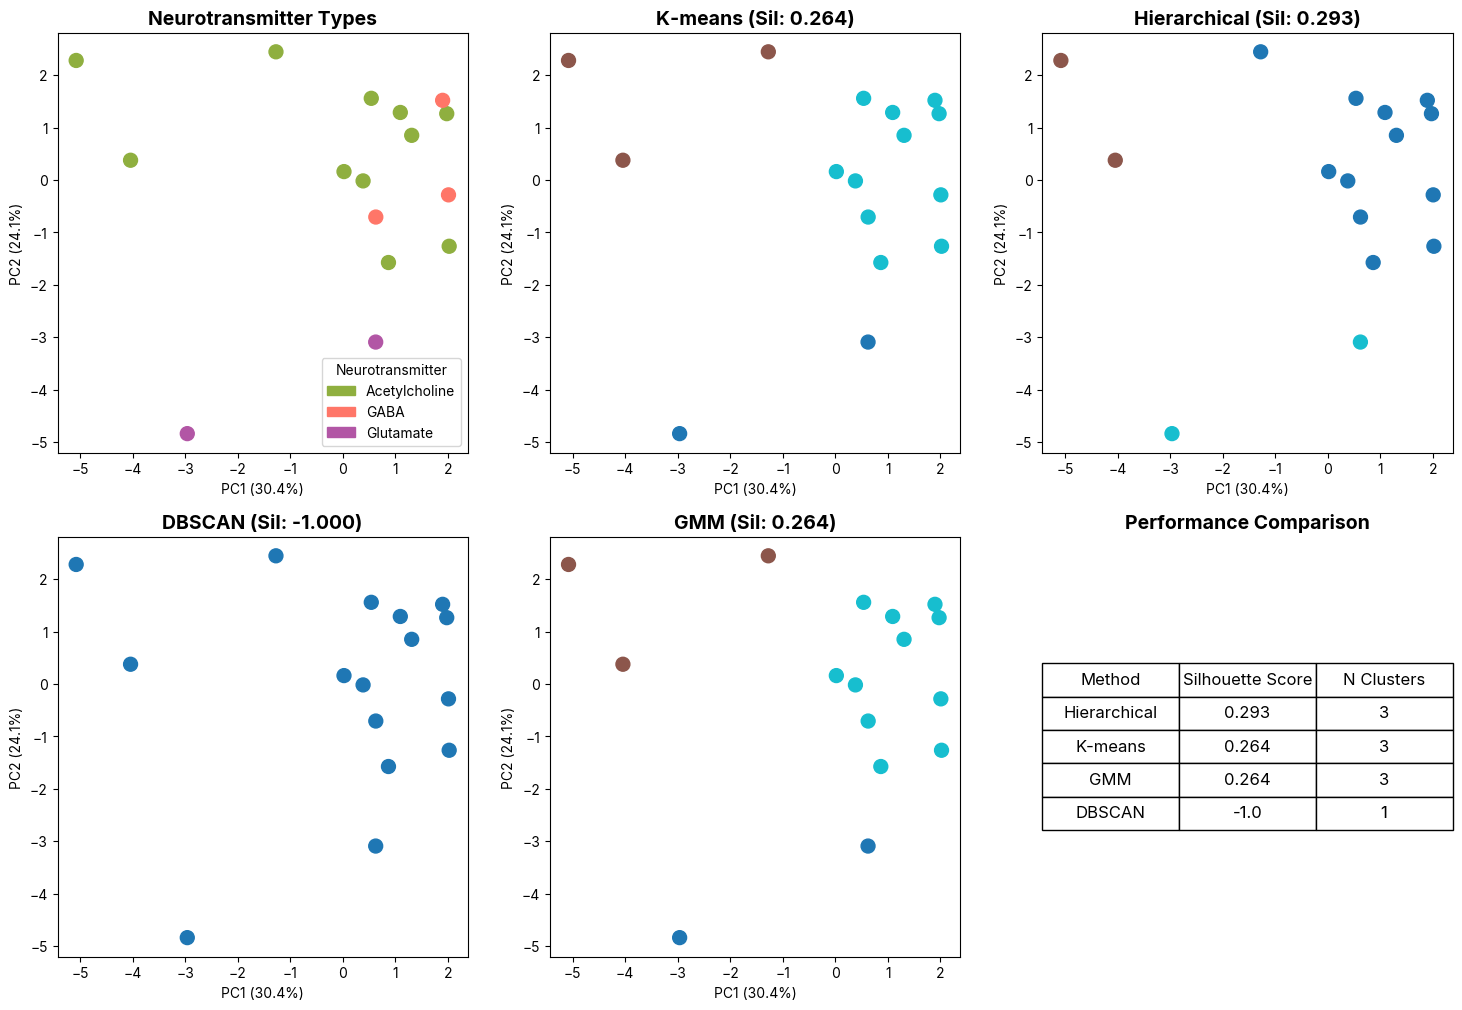

In [ ]:
import matplotlib.patches as mpatches
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

#colors for plot 1
nt_color_map = {
    'Acetylcholine': "#8FAF3F",  # Red
    'GABA': "#FF7668",           # Purple
    'Glutamate': "#B256A5"       # Brown
}

nt_cat = df_clustermbons_clustered['NT'].astype('category')
point_colors = [nt_color_map[nt] for nt in df_clustermbons_clustered['NT']]

# Neurotransmitter types (reference)
axes[0,0].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=point_colors, s=100)
axes[0,0].set_title('Neurotransmitter Types', fontsize=14, weight='bold')
axes[0,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

handles = [mpatches.Patch(color=nt_color_map[nt], label=nt) 
           for nt in nt_cat.cat.categories]
axes[0,0].legend(handles=handles, title='Neurotransmitter')

# K-means
axes[0,1].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=df_clustermbons_clustered['KMeans'], cmap='tab10', s=100)
axes[0,1].set_title(f'K-means (Sil: {sil_kmeans:.3f})', fontsize=14, weight='bold')
axes[0,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# Hierarchical
axes[0,2].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=df_clustermbons_clustered['Hierarchical'], cmap='tab10', s=100)
axes[0,2].set_title(f'Hierarchical (Sil: {sil_hierarchical:.3f})', fontsize=14, weight='bold')
axes[0,2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0,2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# DBSCAN
axes[1,0].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=df_clustermbons_clustered['DBSCAN'], cmap='tab10', s=100)
axes[1,0].set_title(f'DBSCAN (Sil: {sil_dbscan:.3f})', fontsize=14, weight='bold')
axes[1,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# GMM
axes[1,1].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=df_clustermbons_clustered['GMM'], cmap='tab10', s=100)
axes[1,1].set_title(f'GMM (Sil: {sil_gmm:.3f})', fontsize=14, weight='bold')
axes[1,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# Results table
axes[1,2].axis('off')
table_data = results.sort_values('Silhouette Score', ascending=False).round(3)
table = axes[1,2].table(cellText=table_data.values, colLabels=table_data.columns,
                        cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)
axes[1,2].set_title('Performance Comparison', fontsize=14, weight='bold')

# Add MBON labels to best performing plot
best_ax = None
if best_method == 'K-means':
    best_ax = axes[0,1]
elif best_method == 'Hierarchical':
    best_ax = axes[0,2]
elif best_method == 'DBSCAN':
    best_ax = axes[1,0]
elif best_method == 'GMM':
    best_ax = axes[1,1]

if best_ax is not None:
    for i, mbon in enumerate(df_clustermbons_clustered.index):
        best_ax.annotate(mbon, (df_clustermbons_clustered['PCA1'].iloc[i], df_clustermbons_clustered['PCA2'].iloc[i]), 
                        fontsize=8, alpha=0.7)

plt.tight_layout()
plt.suptitle(f'Clustering Method Comparison - Best: {best_method}', fontsize=16, weight='bold', y=1.02)
#plt.savefig(filesavedir + date + '_clustering_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

## dendograms and beyond

In [24]:
n_clusters = 3

linkage_method = 'ward'  # Options: 'ward', 'average', 'complete', 'single'
distance_metric = 'euclidean'  # Options: 'euclidean', 'correlation', 'manhattan'

# Optional: Load connectivity matrix (set to None if you don't have one)
connectivity_file = None  # Example: "connectivity_matrix.csv"

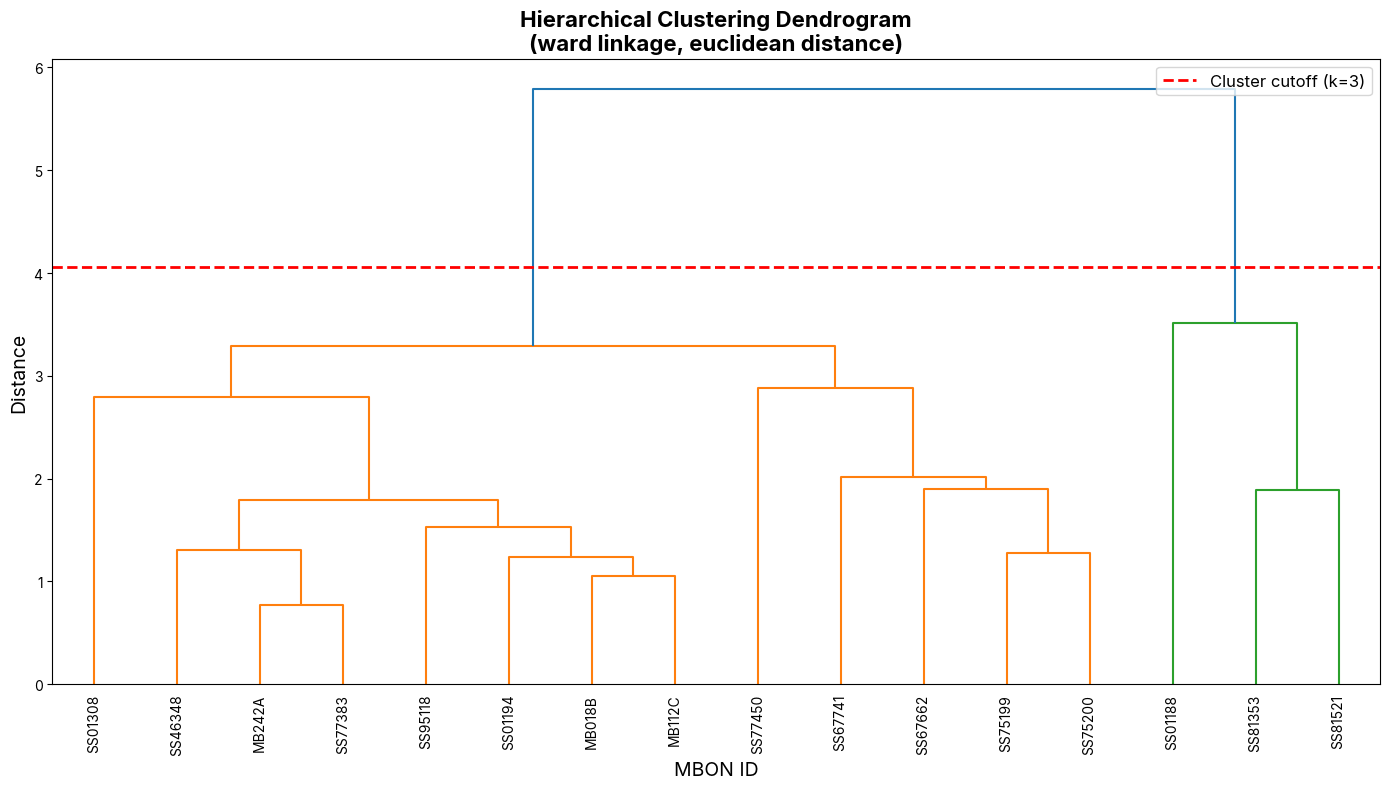

In [25]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import networkx as nx

df_nt_dendogram = datasettouse.drop(columns=['NT'])
Z = linkage(df_nt_dendogram, method=linkage_method, metric=distance_metric)

plt.figure(figsize=(14, 8))
dend = dendrogram(Z, labels=df_nt_dendogram.index, 
                  leaf_font_size=10, leaf_rotation=90,
                  color_threshold=0.7*max(Z[:,2]))

plt.title(f'Hierarchical Clustering Dendrogram\n({linkage_method} linkage, {distance_metric} distance)', 
         fontsize=16, fontweight='bold')
plt.xlabel('MBON ID', fontsize=14)
plt.ylabel('Distance', fontsize=14)
plt.axhline(y=0.7*max(Z[:,2]), c='red', linestyle='--', linewidth=2, 
           label=f'Cluster cutoff (k={n_clusters})')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


In [58]:
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')

# Add cluster labels to dataframe
data_with_clusters = df_nt_dendogram.copy()
data_with_clusters['Cluster'] = cluster_labels

print(f"Cluster assignments:")
print(data_with_clusters['Cluster'].value_counts().sort_index())

print(f"\nMBONs per cluster:")
for cluster_id in range(1, n_clusters+1):
    mbons = data_with_clusters[data_with_clusters['Cluster'] == cluster_id].index.tolist()
    print(f"\nCluster {cluster_id} ({len(mbons)} MBONs):")
    print(f"  {', '.join(mbons)}")

# Save cluster assignments
#data_with_clusters.to_csv('mbon_cluster_assignments.csv')

Cluster assignments:
Cluster
1    13
2     2
3     1
Name: count, dtype: int64

MBONs per cluster:

Cluster 1 (13 MBONs):
  MB018B, MB112C, MB242A, SS01194, SS01308, SS46348, SS67662, SS67741, SS75199, SS75200, SS77383, SS77450, SS95118

Cluster 2 (2 MBONs):
  SS81353, SS81521

Cluster 3 (1 MBONs):
  SS01188


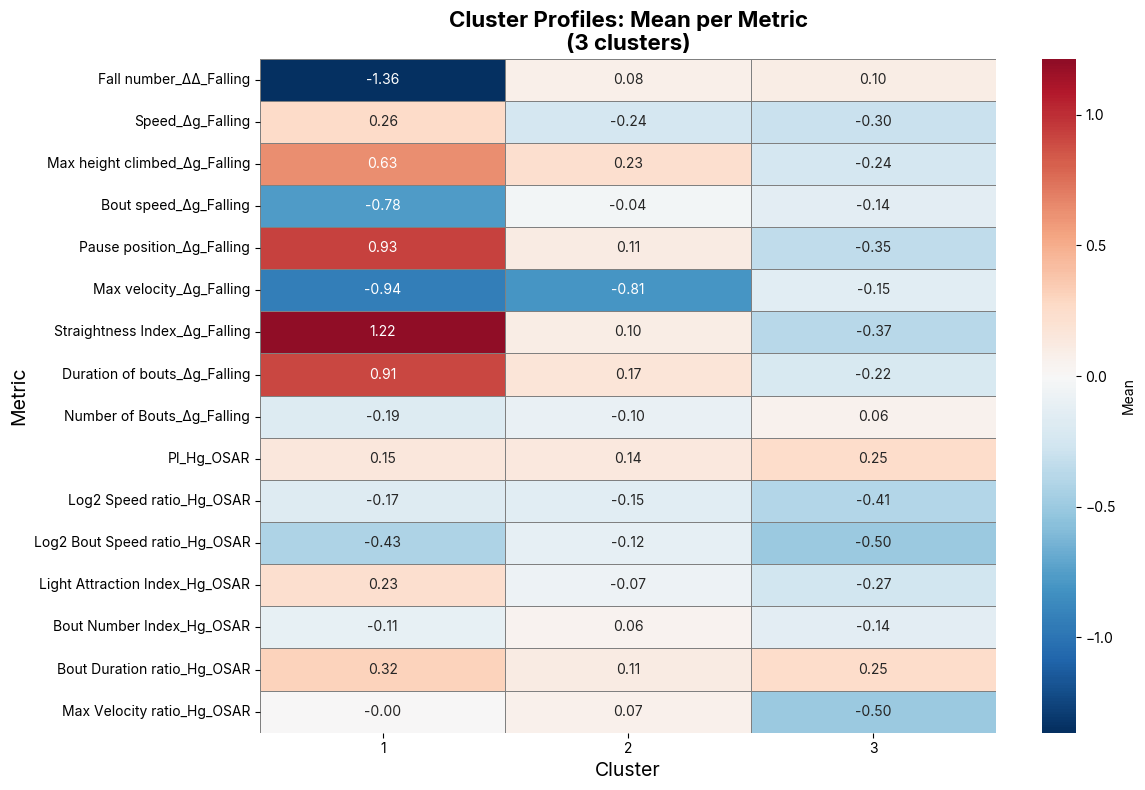

In [46]:
# Calculate mean per cluster for each metric
cluster_means = data_with_clusters.groupby('Cluster').mean()

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means.T, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, cbar_kws={'label': "Mean"},
            linewidths=0.5, linecolor='gray')
plt.title(f"Cluster Profiles: Mean per Metric\n({n_clusters} clusters)", 
         fontsize=16, fontweight='bold')
plt.xlabel('Cluster', fontsize=14)
plt.ylabel('Metric', fontsize=14)
plt.tight_layout()
plt.show()

## PCA metric analysis

In [59]:
# Standardize data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_nt_dendogram)

# Perform PCA
pca = PCA()
pca_result = pca.fit_transform(data_scaled)

# Extract loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=df_nt_dendogram.columns
)

# Print variance explained
print("="*60)
print("PCA VARIANCE EXPLAINED")
print("="*60)
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"PC{i+1}: {var*100:.2f}%")
print(f"\nCumulative (PC1+PC2): {sum(pca.explained_variance_ratio_[:2])*100:.2f}%")

# Save loadings
# loadings.to_csv('pca_loadings.csv')

PCA VARIANCE EXPLAINED
PC1: 27.51%
PC2: 25.03%
PC3: 13.29%
PC4: 13.06%
PC5: 6.28%

Cumulative (PC1+PC2): 52.54%


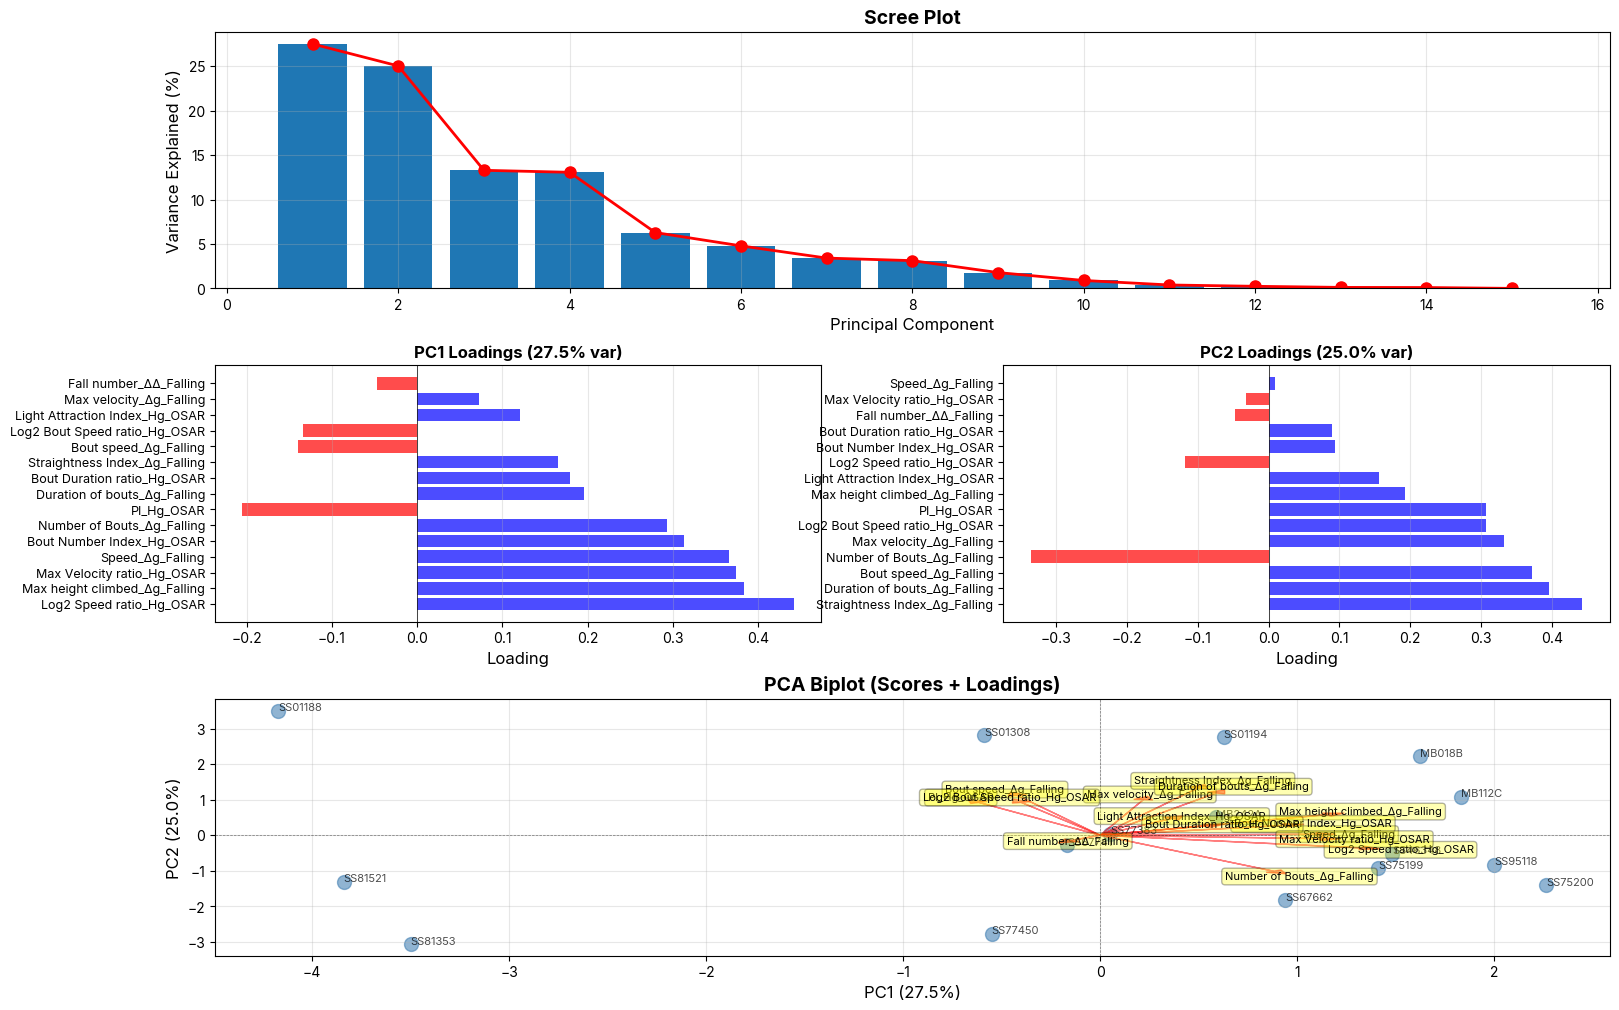


✓ PCA visualization saved as 'pca_loadings.png'


In [60]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Scree plot
ax1 = fig.add_subplot(gs[0, :])
ax1.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_*100)
ax1.plot(range(1, len(pca.explained_variance_ratio_)+1), 
         pca.explained_variance_ratio_*100, 'ro-', linewidth=2, markersize=8)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Variance Explained (%)', fontsize=12)
ax1.set_title('Scree Plot', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. PC1 loadings
ax2 = fig.add_subplot(gs[1, 0])
pc1_loadings = loadings['PC1'].sort_values(key=abs, ascending=False)
colors = ['red' if x < 0 else 'blue' for x in pc1_loadings]
ax2.barh(range(len(pc1_loadings)), pc1_loadings, color=colors, alpha=0.7)
ax2.set_yticks(range(len(pc1_loadings)))
ax2.set_yticklabels(pc1_loadings.index, fontsize=9)
ax2.set_xlabel('Loading', fontsize=12)
ax2.set_title(f'PC1 Loadings ({pca.explained_variance_ratio_[0]*100:.1f}% var)', 
              fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3, axis='x')

# 3. PC2 loadings
ax3 = fig.add_subplot(gs[1, 1])
pc2_loadings = loadings['PC2'].sort_values(key=abs, ascending=False)
colors = ['red' if x < 0 else 'blue' for x in pc2_loadings]
ax3.barh(range(len(pc2_loadings)), pc2_loadings, color=colors, alpha=0.7)
ax3.set_yticks(range(len(pc2_loadings)))
ax3.set_yticklabels(pc2_loadings.index, fontsize=9)
ax3.set_xlabel('Loading', fontsize=12)
ax3.set_title(f'PC2 Loadings ({pca.explained_variance_ratio_[1]*100:.1f}% var)', 
              fontsize=12, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax3.grid(True, alpha=0.3, axis='x')

# 4. Biplot
ax4 = fig.add_subplot(gs[2, :])

# Plot scores
ax4.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6, s=100, c='steelblue')

# Add MBON labels
for i, mbon in enumerate(df_nt_dendogram.index):
    ax4.annotate(mbon, (pca_result[i, 0], pca_result[i, 1]),
                fontsize=8, alpha=0.7)

# Plot loading vectors
scale = 3
for i, metric in enumerate(df_nt_dendogram.columns):
    ax4.arrow(0, 0, loadings.iloc[i, 0]*scale, loadings.iloc[i, 1]*scale,
             head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.5)
    ax4.text(loadings.iloc[i, 0]*scale*1.15, loadings.iloc[i, 1]*scale*1.15,
            metric, fontsize=8, ha='center', va='center', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax4.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax4.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax4.set_title('PCA Biplot (Scores + Loadings)', fontsize=14, fontweight='bold')
ax4.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
ax4.axvline(x=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
ax4.grid(True, alpha=0.3)

plt.show()

print("\n✓ PCA visualization saved as 'pca_loadings.png'")

In [62]:
print("="*60)
print("TOP LOADINGS (by absolute value)")
print("="*60)

print("\nPC1 - Top 5 metrics:")
print(loadings['PC1'].abs().sort_values(ascending=False).head())

print("\nPC2 - Top 5 metrics:")
print(loadings['PC2'].abs().sort_values(ascending=False).head())

print("\n" + "="*60)
print("INTERPRETATION:")
print("="*60)
print("- Positive loading (blue): Metric increases with PC score")
print("- Negative loading (red): Metric decreases with PC score")
print("- High absolute value: Strong contribution to that PC")

TOP LOADINGS (by absolute value)

PC1 - Top 5 metrics:
Log2 Speed ratio_Hg_OSAR         0.442029
Max height climbed_Δg_Falling    0.383363
Max Velocity ratio_Hg_OSAR       0.374296
Speed_Δg_Falling                 0.365574
Bout Number Index_Hg_OSAR        0.313225
Name: PC1, dtype: float64

PC2 - Top 5 metrics:
Straightness Index_Δg_Falling    0.443228
Duration of bouts_Δg_Falling     0.395528
Bout speed_Δg_Falling            0.372578
Number of Bouts_Δg_Falling       0.336158
Max velocity_Δg_Falling          0.332436
Name: PC2, dtype: float64

INTERPRETATION:
- Positive loading (blue): Metric increases with PC score
- Negative loading (red): Metric decreases with PC score
- High absolute value: Strong contribution to that PC


## network diagrams

In [63]:
data_with_clusters

,Fall number_ΔΔ_Falling,Speed_Δg_Falling,Max height climbed_Δg_Falling,Bout speed_Δg_Falling,Max velocity_Δg_Falling,Straightness Index_Δg_Falling,Duration of bouts_Δg_Falling,Number of Bouts_Δg_Falling,PI_Hg_OSAR,Log2 Speed ratio_Hg_OSAR,Log2 Bout Speed ratio_Hg_OSAR,Light Attraction Index_Hg_OSAR,Bout Number Index_Hg_OSAR,Bout Duration ratio_Hg_OSAR,Max Velocity ratio_Hg_OSAR,Cluster
MBON,,,,,,,,,,,,,,,,
MB018B,0.076,-0.350,0.293,0.188,0.412,0.210,0.146,-0.384,0.402923,0.113780,-0.189276,0.284107,0.145590,0.155396,0.347169,1
MB112C,-0.456,-0.307,0.285,-0.329,-0.362,0.209,0.048,-0.016,0.244231,0.186355,0.392273,0.065169,0.171952,0.214931,0.395470,1
MB242A,-0.341,-0.413,-0.435,-0.291,-0.469,0.020,0.166,-0.600,-0.131655,0.062215,0.178585,0.138073,-0.117794,-0.002582,0.151006,1
SS01188,0.329,-0.945,-0.942,1.612,0.345,0.101,-0.077,-2.039,0.382887,-1.015328,0.428199,-0.264349,-0.754269,-0.238888,-0.468508,3
SS01194,-0.578,-0.550,0.237,0.318,0.308,0.407,0.169,-0.863,0.254055,-0.157406,-0.052071,0.297878,-0.148192,0.179373,0.084884,1
SS01308,0.009,-0.061,0.712,0.474,0.065,0.144,0.346,-0.637,0.248447,-0.559452,1.193882,-0.481216,-0.841967,-0.352970,0.063963,1
SS46348,-0.502,-0.609,0.200,-0.671,-0.175,0.081,-0.114,0.126,-0.467341,0.226340,0.020302,0.041174,-0.302430,-0.216989,0.336238,1
SS67662,0.036,0.235,-0.657,-0.165,0.064,-0.969,-0.348,0.491,-0.319966,-0.085534,-0.098383,-0.677690,0.101335,-0.233215,0.360790,1
SS67741,0.894,-0.241,0.151,-0.168,-0.167,-0.567,-0.787,0.340,0.542885,-0.435818,0.068477,0.443361,-0.014714,0.023694,-0.045407,1


In [64]:
# Create network graph
G = nx.Graph()

# Add nodes (MBONs)
for mbon in data_with_clusters.index:
    cluster = data_with_clusters.loc[mbon, 'Cluster']
    G.add_node(mbon, cluster=cluster)

# Add edges based on connectivity or correlation
if connectivity_file is not None:
    # Load connectivity matrix
    connectivity_matrix = pd.read_csv(connectivity_file, index_col=0)
    for i, mbon1 in enumerate(connectivity_matrix.index):
        for j, mbon2 in enumerate(connectivity_matrix.columns):
            if i < j and connectivity_matrix.iloc[i, j] > 0:
                G.add_edge(mbon1, mbon2, weight=connectivity_matrix.iloc[i, j])
    print("Using provided connectivity matrix for edges")
else:
    # Use correlation-based connectivity
    data_for_corr = data_with_clusters.drop('Cluster', axis=1)
    corr_matrix = data_for_corr.T.corr()
    
    threshold = 0.5  # Adjust this if needed
    for i, mbon1 in enumerate(corr_matrix.index):
        for j, mbon2 in enumerate(corr_matrix.columns):
            if i < j and abs(corr_matrix.iloc[i, j]) > threshold:
                G.add_edge(mbon1, mbon2, weight=abs(corr_matrix.iloc[i, j]))
    print(f"Using correlation-based edges (threshold={threshold})")

print(f"\nNetwork Statistics:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
if G.edges():
    print(f"  Average degree: {sum(dict(G.degree()).values())/G.number_of_nodes():.2f}")
    print(f"  Network density: {nx.density(G):.3f}")

Using correlation-based edges (threshold=0.5)

Network Statistics:
  Nodes: 16
  Edges: 18
  Average degree: 2.25
  Network density: 0.150


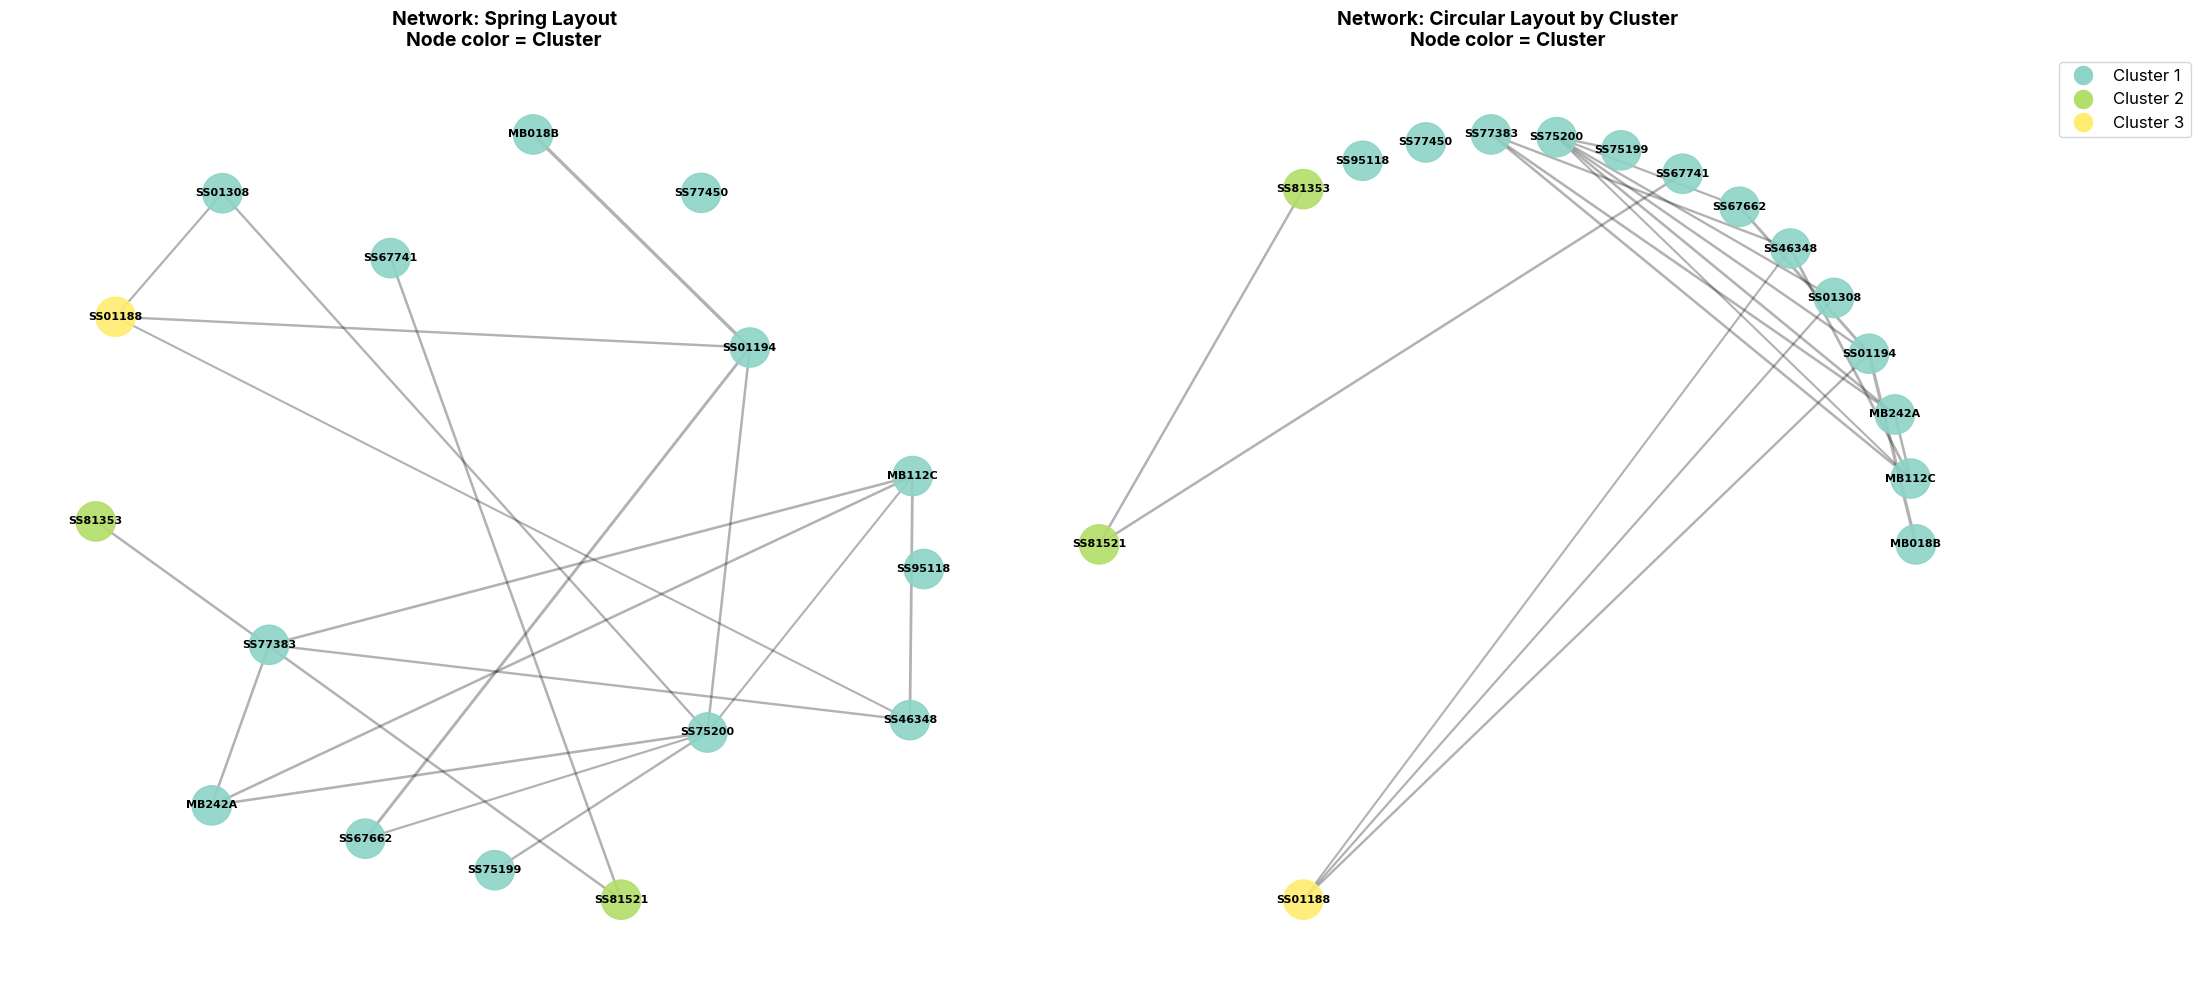


✓ Network diagram saved as 'mbon_network.png'


In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# Define colors for clusters
cluster_colors = plt.cm.Set3(np.linspace(0, 1, n_clusters))
color_map = {i+1: cluster_colors[i] for i in range(n_clusters)}
node_colors = [color_map[G.nodes[node]['cluster']] for node in G.nodes()]

# Layout 1: Spring layout
pos1 = nx.spring_layout(G, k=2, iterations=50, seed=42)

nx.draw_networkx_nodes(G, pos1, node_color=node_colors, node_size=800, 
                      alpha=0.9, ax=ax1)
nx.draw_networkx_labels(G, pos1, font_size=8, font_weight='bold', ax=ax1)

if G.edges():
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    nx.draw_networkx_edges(G, pos1, alpha=0.3, width=[w*3 for w in weights], ax=ax1)

ax1.set_title('Network: Spring Layout\nNode color = Cluster', 
              fontsize=14, fontweight='bold')
ax1.axis('off')

# Layout 2: Circular layout grouped by cluster
pos2 = {}
cluster_nodes = {}
for node in G.nodes():
    cluster = G.nodes[node]['cluster']
    if cluster not in cluster_nodes:
        cluster_nodes[cluster] = []
    cluster_nodes[cluster].append(node)

angle = 0
for cluster in sorted(cluster_nodes.keys()):
    nodes = cluster_nodes[cluster]
    cluster_angle_step = (2 * np.pi / n_clusters) / len(nodes)
    for i, node in enumerate(nodes):
        x = np.cos(angle + i * cluster_angle_step)
        y = np.sin(angle + i * cluster_angle_step)
        pos2[node] = (x, y)
    angle += 2 * np.pi / n_clusters

nx.draw_networkx_nodes(G, pos2, node_color=node_colors, node_size=800,
                      alpha=0.9, ax=ax2)
nx.draw_networkx_labels(G, pos2, font_size=8, font_weight='bold', ax=ax2)

if G.edges():
    nx.draw_networkx_edges(G, pos2, alpha=0.3, width=[w*3 for w in weights], ax=ax2)

ax2.set_title('Network: Circular Layout by Cluster\nNode color = Cluster', 
              fontsize=14, fontweight='bold')
ax2.axis('off')

# Add legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=color_map[i+1], 
                              markersize=15, label=f'Cluster {i+1}')
                  for i in range(n_clusters)]
ax2.legend(handles=legend_elements, loc='upper left', fontsize=12,
          bbox_to_anchor=(1.05, 1))

plt.tight_layout()

plt.show()

print("\n✓ Network diagram saved as 'mbon_network.png'")

In [41]:
# Calculate pairwise distances between clusters
cluster_distances = pdist(cluster_means, metric='euclidean')
dist_matrix = squareform(cluster_distances)

# Convert to similarity
max_dist = np.max(dist_matrix)
similarity_matrix = 1 - (dist_matrix / max_dist)

# Create graph
G_cluster = nx.Graph()

for i in range(n_clusters):
    G_cluster.add_node(f"Cluster {i+1}")

# Add edges (similarity > 0.3)
threshold = 0.3
for i in range(n_clusters):
    for j in range(i+1, n_clusters):
        if similarity_matrix[i, j] > threshold:
            G_cluster.add_edge(f"Cluster {i+1}", f"Cluster {j+1}", 
                              weight=similarity_matrix[i, j])

# Plot
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G_cluster, k=3, iterations=50)

nx.draw_networkx_nodes(G_cluster, pos, node_size=3000, node_color='lightblue',
                      alpha=0.9)
nx.draw_networkx_labels(G_cluster, pos, font_size=14, font_weight='bold')

if G_cluster.edges():
    edges = G_cluster.edges()
    weights = [G_cluster[u][v]['weight'] for u, v in edges]
    nx.draw_networkx_edges(G_cluster, pos, width=[w*5 for w in weights], 
                          alpha=0.6)
    
    edge_labels = {(u, v): f"{G_cluster[u][v]['weight']:.2f}" for u, v in edges}
    nx.draw_networkx_edge_labels(G_cluster, pos, edge_labels, font_size=10)

plt.title('Cluster Similarity Network\n(Edge width = similarity)', 
         fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n✓ Cluster similarity network saved as 'cluster_similarity_network.png'")

NameError: name 'cluster_means' is not defined